In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from scipy.datasets import electrocardiogram

# Load authentic continuous acoustic/wave signal array (360 Hz sample rate)
raw_signal = electrocardiogram()

# Segment raw continuous signal into 1D seismic trace windows (size 180 = 0.5s windows)
window_size = 180
num_windows = len(raw_signal) // window_size
X_raw = raw_signal[:num_windows * window_size].reshape(num_windows, 1, window_size)

# Classify trace windows based on peak amplitude thresholds
# Class 0: Baseline Noise / Quiet Reservoir
# Class 1: P-Wave Arrival (Low Amplitude Signal)
# Class 2: Micro-Seismic Event / Fracture (High Amplitude Event)
max_amps = np.max(np.abs(X_raw), axis=2).flatten()
y_raw = np.where(max_amps < 0.8, 0, np.where(max_amps < 1.8, 1, 2))

# Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.25, random_state=42, stratify=y_raw)

# Convert to PyTorch Tensors
train_dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
test_dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Authentic Signal Pipeline Loaded!")
print(f"Total Traces: {len(X_raw)} | Train: {len(X_train)} | Test: {len(X_test)}")
print("Class Counts:", np.bincount(y_raw))

Authentic Signal Pipeline Loaded!
Total Traces: 600 | Train: 450 | Test: 150
Class Counts: [ 38 445 117]


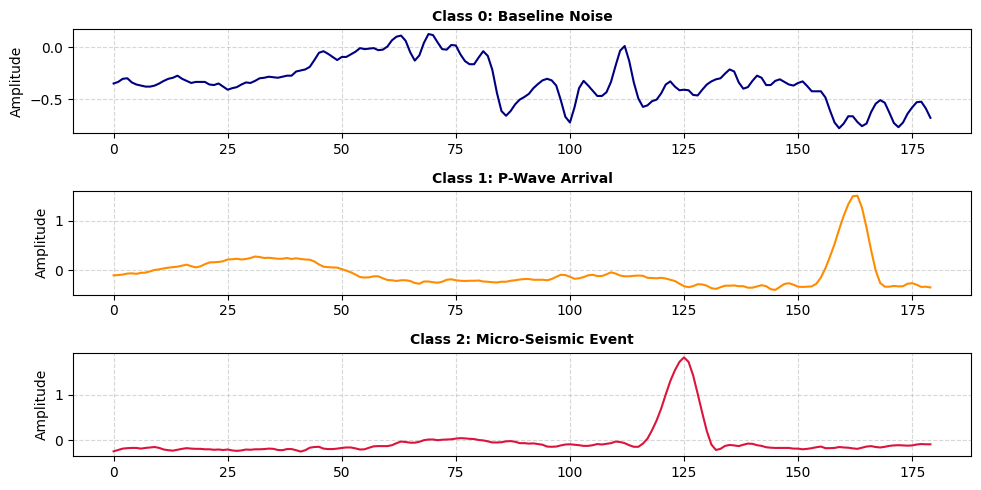

In [8]:
plt.figure(figsize=(10, 5))
class_names = ['Baseline Noise', 'P-Wave Arrival', 'Micro-Seismic Event']

for i in range(3):
    idx = np.where(y_raw == i)[0][0]
    plt.subplot(3, 1, i+1)
    plt.plot(X_raw[idx, 0, :], color='navy' if i==0 else ('darkorange' if i==1 else 'crimson'))
    plt.title(f"Class {i}: {class_names[i]}", fontsize=10, fontweight='bold')
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [9]:
class SeismicTrace1DCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(SeismicTrace1DCNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )

        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * (180 // 4), 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cnn_model = SeismicTrace1DCNN(num_classes=3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)

# Training Loop
epochs = 10
print(f"Training 1D CNN on device: {device}...")

for epoch in range(epochs):
    cnn_model.train()
    total_loss = 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(X_b)
        loss = criterion(outputs, y_b)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {total_loss/len(train_loader):.4f}")

Training 1D CNN on device: cpu...
Epoch [1/10] - Loss: 0.6937
Epoch [2/10] - Loss: 0.5787
Epoch [3/10] - Loss: 0.5845
Epoch [4/10] - Loss: 0.4775
Epoch [5/10] - Loss: 0.4042
Epoch [6/10] - Loss: 0.4934
Epoch [7/10] - Loss: 0.4250
Epoch [8/10] - Loss: 0.3426
Epoch [9/10] - Loss: 0.3594
Epoch [10/10] - Loss: 0.3121


--- 1D CNN Seismic Model Performance ---
Accuracy: 80.67%

                     precision    recall  f1-score   support

     Baseline Noise       0.70      0.70      0.70        10
     P-Wave Arrival       0.84      0.92      0.88       111
Micro-Seismic Event       0.67      0.41      0.51        29

           accuracy                           0.81       150
          macro avg       0.73      0.68      0.70       150
       weighted avg       0.79      0.81      0.79       150



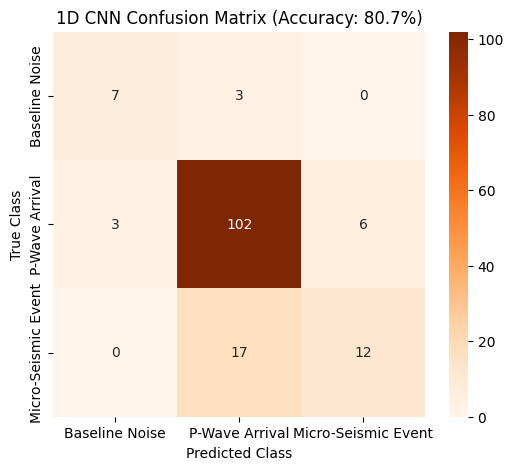

In [10]:
cnn_model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_b, y_b in test_loader:
        X_b = X_b.to(device)
        outputs = cnn_model(X_b)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_b.numpy())

accuracy = accuracy_score(all_targets, all_preds)
print("--- 1D CNN Seismic Model Performance ---")
print(f"Accuracy: {accuracy * 100:.2f}%\n")
print(classification_report(all_targets, all_preds, target_names=class_names))

cm = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title(f'1D CNN Confusion Matrix (Accuracy: {accuracy*100:.1f}%)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()